---
### 01. 머신러닝 실습 2
- [분류] 합격여부 예측
- [변수설명] admit 0/1: 불합격/합격, gre: 시험점수, gpa: 학점, rank: 평가등급
---

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

import warnings
warnings.filterwarnings("ignore")

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
df = pd.read_csv('data/graduate.csv')
print(df.shape)
df.head()

(400, 4)


,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [12]:
#결측치, 변수타입 확인
print(df.isnull().sum())
print('-'*50)
print(df.info())

admit    0
gre      0
gpa      0
rank     0
dtype: int64
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   admit   400 non-null    int64  
 1   gre     400 non-null    int64  
 2   gpa     400 non-null    float64
 3   rank    400 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 12.6 KB
None


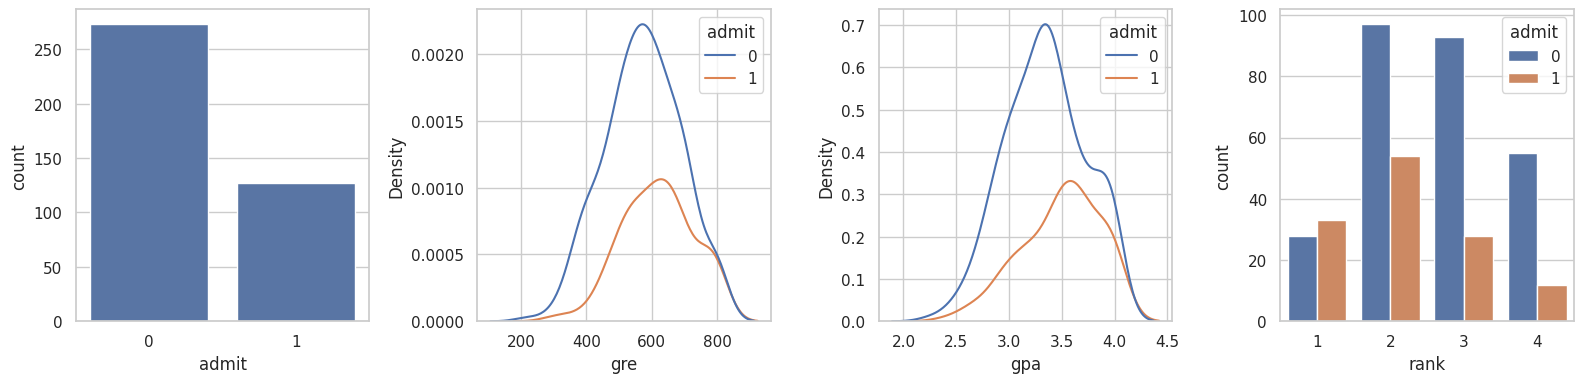

In [13]:
# 분포 확인
fig, axes = plt.subplots(1,4,figsize=(16,4))
sns.countplot(data=df, x='admit', ax=axes[0])
sns.kdeplot(data=df, x='gre', hue='admit', ax=axes[1])
sns.kdeplot(data=df, x='gpa', hue='admit', ax=axes[2])
sns.countplot(data=df, x='rank', hue='admit', ax=axes[3])

plt.tight_layout()
plt.show()

### 데이터 전처리

In [14]:
# 타겟변수 분리
y = df['admit']
X = df.drop('admit', axis=1)

# one-hot 인코딩
X = pd.get_dummies(X, columns=['rank'], drop_first=True, dtype=int)

# 검증데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# scaling
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

#### 모델링

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

model = LogisticRegression()
model.fit(X_train, y_train)

pred = model.predict(X_valid)

#### 평가지표

In [16]:
report = classification_report(y_valid, pred)
print(report)

              precision    recall  f1-score   support

           0       0.73      0.96      0.83        55
           1       0.71      0.20      0.31        25

    accuracy                           0.72        80
   macro avg       0.72      0.58      0.57        80
weighted avg       0.72      0.72      0.67        80



- 정확도는 72%로 나쁘지 않아보이나, macro와 weighted의 차이가 큰것으로 보아 클래스 불균형이 존재하는 것으로 판단됨
- f1을 보면 불합격은 잘 예측하는데 비해, 합격에 대한 예측은 31% 수준에 그침. 즉 데이터에서 다수를 차지하는 불합격자만 잘 맞추는 모델

In [17]:
# 클래스 불균형 대응
model2 = LogisticRegression(class_weight='balanced')
model2.fit(X_train, y_train)
model2.predict(X_valid)

pred2 = model2.predict(X_valid)
report2 = classification_report(y_valid, pred2)
print(report2)

              precision    recall  f1-score   support

           0       0.79      0.69      0.74        55
           1       0.47      0.60      0.53        25

    accuracy                           0.66        80
   macro avg       0.63      0.65      0.63        80
weighted avg       0.69      0.66      0.67        80



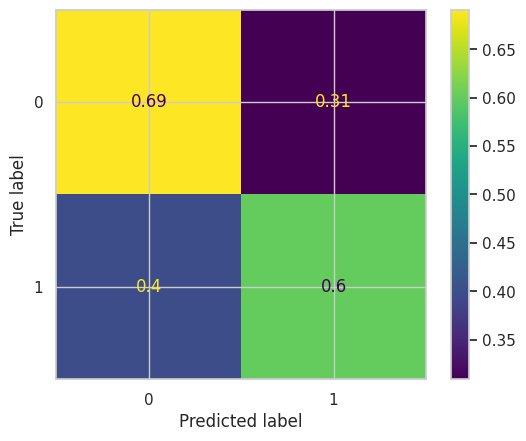

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_valid, pred2,
    normalize='true'
)